# Analisis de ventas por temporalidad

# Objetivos del analisis

Analizar como varian las ventas a lo largo del tiempo para identificar patrones estacionales, tendencias y períodos de mayor o menor desempeño.

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


In [116]:
df = pd.read_csv('../Data/VentaHipermercado.csv')
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


# EDA

In [117]:
df.shape

(9800, 18)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Convercion de la columna **Order Date** a DateTime

In [119]:
df['Order Date'] = df['Order Date'].apply(
    pd.to_datetime,
    dayfirst=True,
    errors='coerce'
)

Se crean las columnas de Year, Month y Quarter, para poder realizar el analisis temporal de las ventas

In [120]:
df['Year'] = df['Order Date'].dt.year.astype('Int64')
df['Month'] = df['Order Date'].dt.month.astype('Int64')
df['Quarter'] = df['Order Date'].dt.quarter.astype('Int64')

### Ventas por año

In [121]:
def formato_miles(x, pos):
    return f'{int(x):,}'.replace(',', '.')

<Axes: xlabel='Year'>

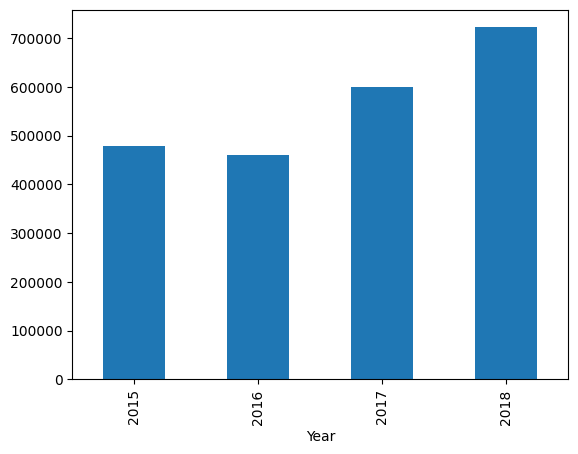

In [168]:
df.groupby('Year')['Sales'].sum().sort_index().plot(kind='bar')

### Ventas por trimestre

In [123]:
tablaTrimestral = pd.pivot_table(
    df,
    values='Sales',
    index='Quarter',
    columns='Year',
    aggfunc='sum'
).sort_index()

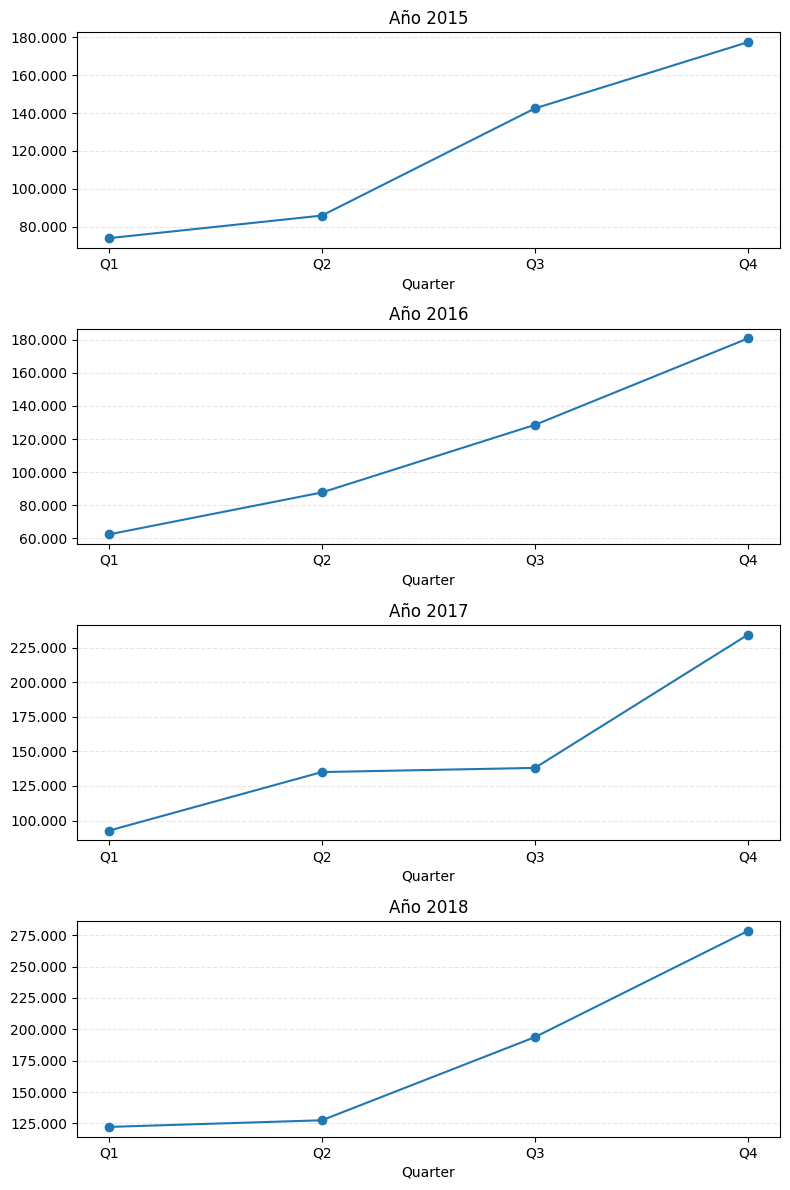

In [169]:
trimestre = ['Q1','Q2','Q3','Q4']

fig, axes = plt.subplots(
    len(tablaTrimestral.columns),
    1,
    figsize=(8, 3*len(tablaTrimestral.columns)),

)

for ax, year in zip(axes, tablaTrimestral.columns):
    tablaTrimestral[year].plot(ax=ax, marker='o')
    ax.set_title(f'Año {year}')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(trimestre)
    ax.yaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()


## Porcentaje que comprende cada trimestre

In [125]:
tablaTrimestral.apply(lambda x: x/x.sum()*100, axis=0).style.format('{:,.0f}%')

Year,2015,2016,2017,2018
Quarter,,,,
1,15%,14%,15%,17%
2,18%,19%,23%,18%
3,30%,28%,23%,27%
4,37%,39%,39%,39%


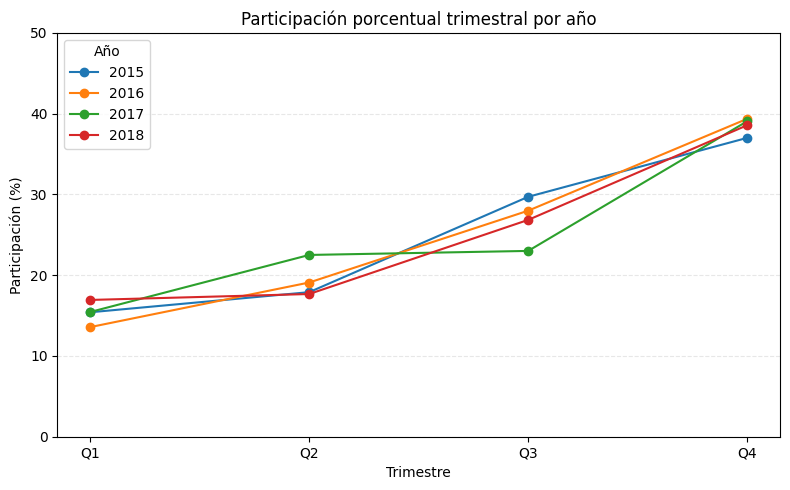

In [167]:
tabla_pct = tablaTrimestral.apply(lambda x: x / x.sum() * 100, axis=0)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

for year in tabla_pct.columns:
    ax.plot(
        tabla_pct.index,
        tabla_pct[year],
        marker='o',
        label=str(year)
    )

ax.set_title('Participación porcentual trimestral por año')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Participación (%)')
ax.set_ylim(0, 50)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Año')
ax.set_xticks(range(1, 5))
ax.set_xticklabels(trimestre)

plt.tight_layout()
plt.show()





## Insight

1. **Estacionalidad concentrada en el último trimestre:**
    * Las ventas se concentran de forma consistente en el Q4, representando cerca del 40% del total anual en todos los años analizados, lo que evidencia una fuerte estacionalidad hacia el cierre del año.

2. **Q1 estructuralmente bajo pero en crecimiento:**
    * El primer trimestre aporta la menor proporción de ventas anuales (14%–17%), aunque muestra un crecimiento progresivo año a año, indicando una mejora gradual en el desempeño inicial del negocio.


### Crecimiento interanual por trimestre

In [128]:
tablaTrimestral.style.format('{:,.0f}')

Year,2015,2016,2017,2018
Quarter,,,,
1,"73,931","62,358","92,686","122,261"
2,"85,874","87,713","135,061","127,559"
3,"142,523","128,560","138,056","193,816"
4,"177,528","180,805","234,389","278,417"


In [129]:
crecimiento_yoy = tablaTrimestral.pct_change(axis=1) * 100
crecimiento_yoy


Year,2015,2016,2017,2018
Quarter,,,,
1,NaN,-15.654660,48.636631,31.908166
2,NaN,2.141833,53.980125,-5.554921
3,NaN,-9.796621,7.386552,40.388911
4,NaN,1.845694,29.636343,18.784197


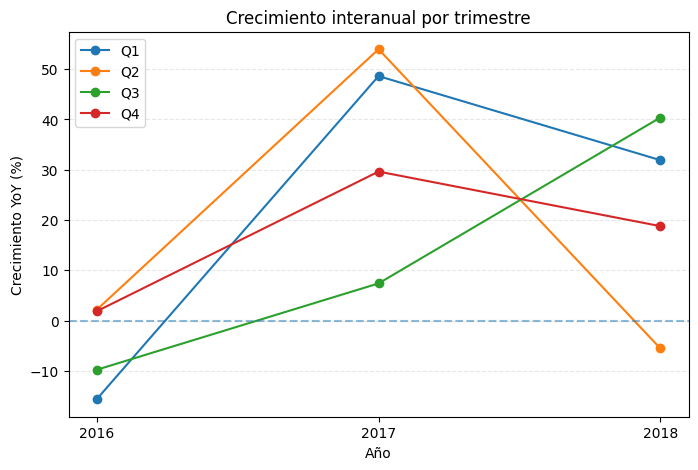

In [130]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
years = crecimiento_yoy.columns.astype(int)

for quarter in crecimiento_yoy.index:
    ax.plot(
        years,
        crecimiento_yoy.loc[quarter],
        marker='o',
        label=f'Q{quarter}'
    )
ax.set_xticks(range(2016, 2019))
ax.set_title('Crecimiento interanual por trimestre')
ax.set_xlabel('Año')
ax.set_ylabel('Crecimiento YoY (%)')
ax.axhline(0, linestyle='--', alpha=0.5)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig(
    "../Images/volatilidadInteranual.svg",
    bbox_inches="tight"
)
plt.show()


## Insight

* El Q4 presenta el crecimiento interanual más estable, manteniéndose positivo en todos los años analizados, lo que refuerza su rol como el trimestre más predecible y consistente del negocio.
* El Q2 muestra la mayor volatilidad interanual, con fuertes crecimientos seguidos de caídas, lo que indica un comportamiento menos predecible en comparación con otros trimestres.

# Modelado Predictivo de ventas
### Pregunta de negocio
¿Es posible predecir las ventas utilizando información temporal (año, trimestre, mes) y otras variables disponibles en el dataset?

En el análisis exploratorio se identificaron patrones de estacionalidad y variaciones significativas entre trimestres. En este bloque se busca evaluar si estos patrones pueden ser capturados por un modelo predictivo.


# Modelo predictivo mensual

Se agregaron las ventas a nivel mensual para aumentar la granularidad temporal y permitir al modelo capturar patrones intra-trimestre antes de reagrupar las predicciones

¿Qué tan bien puedo predecir las ventas trimestrales usando solo tendencia y estacionalidad?

In [142]:
df_mensual = (
    df
    .groupby(['Year', 'Month'], as_index=False)
    .agg({'Sales': 'sum'})
)
df_mensual = df_mensual.sort_values(['Year', 'Month'])

In [143]:
df_mensual['t_m'] = range(1, len(df_mensual) + 1)

Se creó una variable temporal incremental (t_m) para representar el paso del tiempo de forma continua, permitiendo al modelo capturar tendencias a lo largo de los trimestres.

In [144]:
y_m = df_mensual['Sales']
X_m = df_mensual[['t_m', 'Month']]

In [145]:
train_m = df_mensual[df_mensual['Year'] < 2018]
test_m  = df_mensual[df_mensual['Year'] == 2018]

X_train_m = train_m[['t_m', 'Month']]
y_train_m = train_m['Sales']

X_test_m = test_m[['t_m', 'Month']]
y_test_m = test_m['Sales']

El conjunto de entrenamiento se construyó utilizando datos mensuales hasta 2017, reservando el año 2018 como conjunto de prueba, manteniendo el orden temporal.

---

### Random forest mensual

In [152]:
from sklearn.ensemble import RandomForestRegressor

rf_m = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42
)

rf_m.fit(X_train_m, y_train_m)

,n_estimators,300
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [153]:
y_pred_rf_m = rf_m.predict(X_test_m)

In [188]:
# importar metricas para los ejercicos de abajo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_rf_m = mean_absolute_error(y_test_m, y_pred_rf_m)
rmse_rf_m = np.sqrt(mean_squared_error(y_test_m, y_pred_rf_m))
r2_rf_m = r2_score(y_test_m, y_pred_rf_m)

print(f'MAE: {mae_rf_m:,.1f}')
print(f'RMSE: {rmse_rf_m:.1F}')
print(f'R2: {r2_rf_m:.2%}')

MAE: 12,983.5
RMSE: 16736.0
R2: 57.95%


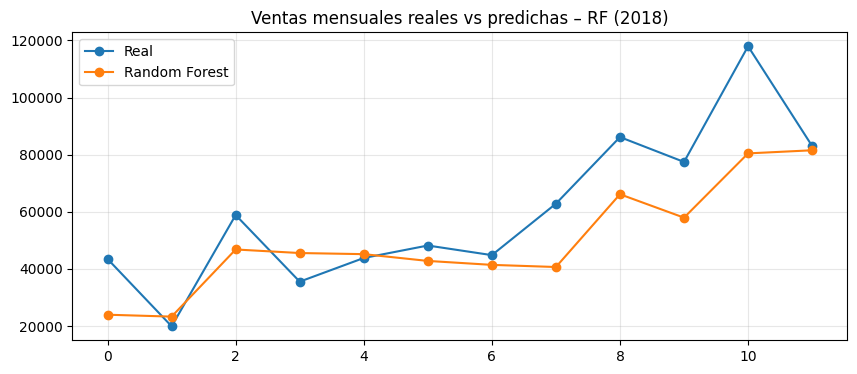

In [155]:
plt.figure(figsize=(10,4))
plt.plot(y_test_m.values, marker='o', label='Real')
plt.plot(y_pred_rf_m, marker='o', label='Random Forest')
plt.title('Ventas mensuales reales vs predichas – RF (2018)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [157]:
test_m = test_m.copy()
test_m['Quarter'] = ((test_m['Month'] - 1) // 3) + 1

Aqui estamos creando la columna **Quarter** para poder identificarlo en nuestro nuevo dataframe , y luego realizar el analisis si pudimos predecir la estacionalidad por trimestre

In [158]:
df_pred_m = test_m[['Year', 'Month', 'Quarter']].copy()
df_pred_m['Sales_real'] = y_test_m.values
df_pred_m['Sales_pred'] = y_pred_rf_m

In [159]:
df_trimestral_pred = (
    df_pred_m
    .groupby(['Year', 'Quarter'], as_index=False)
    .agg({
        'Sales_real': 'sum',
        'Sales_pred': 'sum'
    })
)

In [189]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_q = mean_absolute_error(
    df_trimestral_pred['Sales_real'],
    df_trimestral_pred['Sales_pred']
)

rmse_q = np.sqrt(mean_squared_error(
    df_trimestral_pred['Sales_real'],
    df_trimestral_pred['Sales_pred']
))

r2_q = r2_score(
    df_trimestral_pred['Sales_real'],
    df_trimestral_pred['Sales_pred']
)

print(f'MAE: {mae_q:,.1f}')
print(f'RMSE: {rmse_q:.1F}')
print(f'R2: {r2_q:.2%}')

MAE: 34,562.5
RMSE: 39784.4
R2: 60.33%


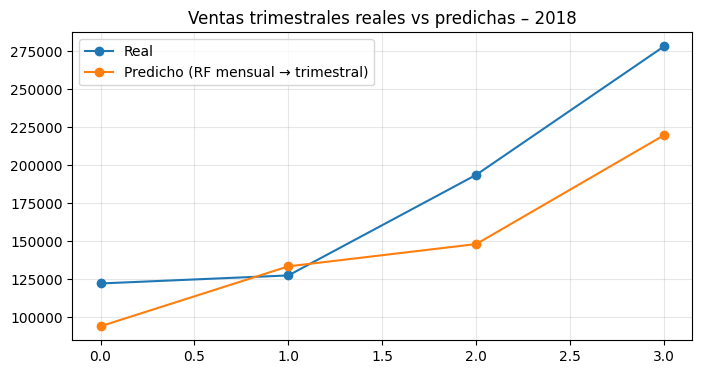

In [161]:
plt.figure(figsize=(8,4))
plt.plot(
    df_trimestral_pred['Sales_real'].values,
    marker='o',
    label='Real'
)
plt.plot(
    df_trimestral_pred['Sales_pred'].values,
    marker='o',
    label='Predicho (RF mensual → trimestral)'
)
plt.title('Ventas trimestrales reales vs predichas – 2018')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Conclucion Modelo Predictivo

Se evaluó un modelo Random Forest tanto a nivel mensual como trimestral con el objetivo de capturar la estacionalidad observada en el análisis exploratorio.

En ambos casos, las métricas obtenidas fueron similares (MAE ≈ 13.000, RMSE ≈ 16.700 y R² ≈ 58%), lo que indica que el modelo no logra mejorar su desempeño al cambiar la granularidad temporal.

Si bien el modelo logra captar parcialmente la estacionalidad general, presenta dificultades para predecir con precisión los picos de ventas, especialmente en períodos de alta volatilidad. Esto se refleja en el valor elevado del RMSE y en un R² moderado.

La similitud de resultados entre el enfoque mensual y trimestral sugiere que la limitada cantidad de datos históricos y la alta variabilidad del negocio restringen la capacidad predictiva del modelo. En este contexto, el análisis exploratorio aporta mayor valor que el modelado supervisado para la toma de decisiones.